In [26]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## exploring the dataset

In [27]:
train=pd.read_csv(r'/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv')
test=pd.read_csv(r'/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/test.csv')

In [28]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [30]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Drop unimportant columns

In [31]:
train.drop(['Cabin','Name','PassengerId'], axis=1, inplace=True)
test.drop(['Cabin', 'Name','PassengerId'],axis=1, inplace=True)

## Handling Missing Values

In [32]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [36]:
train['Age'].fillna(train['Age'].mean(), inplace=True)
train.dropna(subset=['Embarked'], inplace=True)


In [37]:
train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## Handling Duplicates

In [42]:
#check duplicates
print(f"Before {train.duplicated().sum()}")
train.drop_duplicates(inplace=True)
print (f"After {train.duplicated().sum()}")

Before 0
After 0


## Convert Types 

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])

train = pd.get_dummies(train, columns=['Embarked'])

In [46]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,A/5 21171,7.2500,False,False,True
1,1,1,0,38.0,1,0,PC 17599,71.2833,True,False,False
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,1,1,0,35.0,1,0,113803,53.1000,False,False,True
4,0,3,1,35.0,0,0,373450,8.0500,False,False,True


## Generate summary statistics and group-based insights (survival by gender/class)

In [51]:
train['Survived'].value_counts()

Survived
0    540
1    334
Name: count, dtype: int64

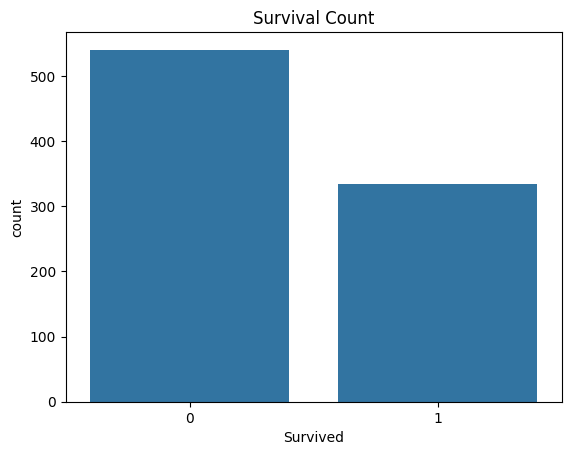

In [52]:
sns.countplot(x='Survived', data=train)
plt.title("Survival Count")
plt.show()

In [53]:
train.groupby('Sex')['Survived'].mean().round(2)

Sex
0    0.75
1    0.19
Name: Survived, dtype: float64

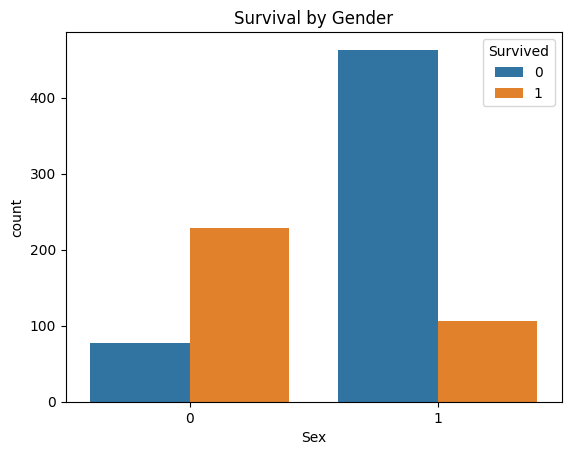

In [54]:
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title("Survival by Gender")
plt.show()

In [55]:
train.groupby('Pclass')['Survived'].mean().round(2)

Pclass
1    0.62
2    0.48
3    0.24
Name: Survived, dtype: float64

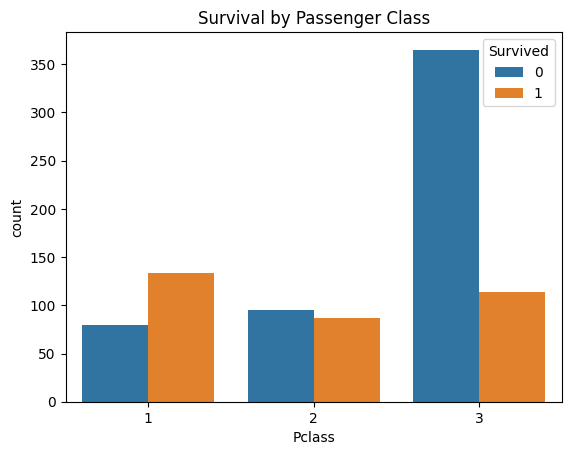

In [58]:
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title("Survival by Passenger Class")
plt.show()

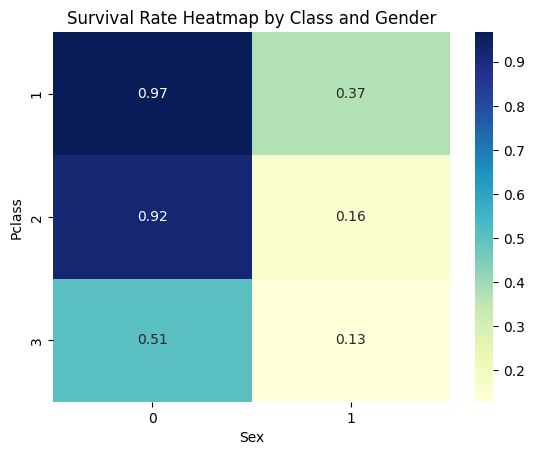

In [61]:
pivot = train.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title("Survival Rate Heatmap by Class and Gender")
plt.show()

## Data insights

Key Insights from Titanic Dataset

Overall Survival Rate

Only ~38% of passengers survived the disaster, while ~62% did not.

This shows the severity of the event and sets a baseline for further analysis.

**Survival by Gender

Females had a much higher survival rate (~75%) compared to males (~19%).

Indicates that women were prioritized during evacuation.

**Survival by Passenger Class

Survival rates decreased with lower passenger class:

1st Class: 62%

2nd Class: 48%

3rd Class: 24%

Passengers in higher classes had better access to lifeboats and resources.

**Survival by Gender & Class

Combining gender and class shows that female 1st-class passengers had the highest survival rates,
while male 3rd-class passengers had the lowest survival rates.

**Age Distribution

Younger passengers (especially children) had slightly higher chances of survival.

The distribution of ages shows most passengers were adults, but age impacted survival marginally.

Fare vs Survival

Passengers who paid higher fares (mostly in higher classes) were more likely to survive.

Suggests fare indirectly correlates with survival probability.

Correlations

Pclass negatively correlates with Survived (lower class → lower survival).

Fare positively correlates with Survived (higher fare → higher survival).

Gender has a strong effect, with females more likely to survive.